In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import cudaq
import sys
import os
import shutil
import faulthandler
from scipy.linalg import expm
from math import sqrt
from tqdm import tqdm
import torch
from typing import List, Tuple
sys.path.append(os.path.abspath(".."))
from Utils.qaoaCUDAQ import po_normalize, ret_cov_to_QUBO, qubo_to_ising, process_ansatz_values, kernel_flipped, all_state_to_return, find_budget

In [2]:
e = 0
N_ASSETS = 3
TARGET_QUBIT_IN = 2
q = 1.5
lamb = 0.05

device = torch.device("cuda")
DUPLICATE_ASSET = False
min_P, max_P = 108, 216

In [3]:
data_cov_pd = pd.read_csv("../dataset/top_50_us_stocks_data_20250526_011226_covariance.csv")
data_ret_p_pd = pd.read_csv("../dataset/top_50_us_stocks_returns_price.csv")

data_ret_p_pd = data_ret_p_pd[(data_ret_p_pd["Price"] > min_P) & (data_ret_p_pd["Price"] < max_P)]
data_cov_pd = data_cov_pd.loc[data_cov_pd["Ticker"].isin(data_ret_p_pd["Ticker"])].reset_index(drop=True)
data_cov_pd = data_cov_pd[["Ticker"] + data_cov_pd["Ticker"].tolist()]

In [4]:
np.random.seed(911 + 991 * e + 997 * N_ASSETS)
state = np.random.get_state()
# asset_idx = np.random.choice(data_cov_pd.shape[0], max(TARGET_ASSET), replace=False)
asset_idx = np.random.choice(data_cov_pd.shape[0], N_ASSETS, replace=DUPLICATE_ASSET)
# print(asset_idx)
# asset_idx = np.array([0, 18, 27, 32, 41])
# data_cov = data_cov_pd.drop("Ticker", axis=1)
data_cov = data_cov_pd.drop("Ticker", axis=1).to_numpy()[asset_idx, :][:, asset_idx]
stock_names = data_ret_p_pd["Company_Name"].to_numpy()[asset_idx]
# print("Selected Stocks: ", stock_names)
data_ret_p = data_ret_p_pd.drop("Ticker", axis=1)
# print(data_ret_p.index[asset_idx].to_numpy())
asset_idx_raw = data_ret_p.index[asset_idx].to_numpy()
data_ret_p = data_ret_p.drop("Company_Name", axis=1).to_numpy()[asset_idx, :]

data_ret = data_ret_p[:, 0]
data_p = data_ret_p[:, 1]
print("Selected Stocks: ", stock_names)
print("Selected Stocks Price: ", data_p)
print("Selected Stocks Return: ", data_ret)

Selected Stocks:  ['Philip Morris International Inc.' 'Abbott Laboratories' 'Broadcom Inc.']
Selected Stocks Price:  [158.72999573 132.0383606  167.42999268]
Selected Stocks Return:  [0.00060737 0.00060593 0.00142008]


In [25]:
np.random.set_state(state)
weighted = np.random.uniform(0, 1)
B_mi, B_ma = find_budget(TARGET_QUBIT_IN * N_ASSETS, data_p, min_P, max_P, min_mix_mode=True)
B = B_mi * weighted + B_ma * (1 - weighted)

P = data_p[:N_ASSETS]
ret = data_ret[:N_ASSETS]
cov = data_cov[:N_ASSETS, :N_ASSETS]
P_bb, ret_bb, cov_bb, n_qubit, n_max, C = po_normalize(B, P, ret, cov)
TARGET_QUBIT = n_qubit

# QUBOs of MAX PROBLEM
QU = ret_cov_to_QUBO(ret_bb, cov_bb, P_bb, lamb, q)
QU_lamb = ret_cov_to_QUBO(np.zeros_like(ret_bb), np.zeros_like(cov_bb), P_bb, lamb, 0.0)
QU_eval = ret_cov_to_QUBO(ret_bb, cov_bb, P_bb, 0.0, q)
QU_return = ret_cov_to_QUBO(ret_bb, np.zeros_like(cov_bb), np.zeros_like(P_bb), 0.0, 0.0)
QU_risk = ret_cov_to_QUBO(np.zeros_like(ret_bb), cov_bb, np.zeros_like(P_bb), 0.0, q)

# 3SAT
# TARGET_QUBIT = 7
# QU = [[0, -2, 2, -1, 1, -1, 1], [0, 1, 0, -1, -1, 1, -1], [0, 0, -1, -1, -1, -1, 1], [0, 0, 0, 2, 0, 0, 0], [0, 0, 0, 0, 1, 0, 0], [0, 0, 0, 0, 0, 1, 0], [0, 0, 0, 0, 0, 0, 0]]
# QU = np.array(QU)
# # QU = QU + QU.T - np.diag(QU.diagonal())
# QU = -QU

# Hamiltonians of MIN PROBLEM
H_ansatz = -qubo_to_ising(QU, lamb).canonicalize() * 1e1
# H_lamb = -qubo_to_ising(QU_lamb, lamb).canonicalize()
# H_eval = -qubo_to_ising(QU_eval, 0.0).canonicalize()
# H_return = -qubo_to_ising(QU_return, 0.0).canonicalize()
# H_risk = -qubo_to_ising(QU_risk, 0.0).canonicalize()

idx_1_use, coeff_1_use, idx_2_a_use, idx_2_b_use, coeff_2_use = process_ansatz_values(H_ansatz)

H = sum_i c_i Z_i + sum_ij c_ij Z_i Z_j

In [26]:
print(H_ansatz)

(0.290123+0i) + (-0.075+0i) * Z0 + (-0.15+0i) * Z1 + (0.0563294+0i) * Z0Z1 + (-0.0624117+0i) * Z2 + (0.0233631+0i) * Z0Z2 + (-0.124823+0i) * Z3 + (0.0467262+0i) * Z0Z3 + (-0.0784169+0i) * Z4 + (0.0296316+0i) * Z0Z4 + (-0.156834+0i) * Z5 + (0.0592633+0i) * Z0Z5 + (0.0467262+0i) * Z1Z2 + (0.0934524+0i) * Z1Z3 + (0.0592633+0i) * Z1Z4 + (0.118527+0i) * Z1Z5 + (0.038983+0i) * Z2Z3 + (0.0246645+0i) * Z2Z4 + (0.0493289+0i) * Z2Z5 + (0.0493289+0i) * Z3Z4 + (0.0986579+0i) * Z3Z5 + (0.0631179+0i) * Z4Z5


In [23]:
# aa = np.array([0, 1, 0, 1, 0, 1, 0])
# aa = np.array([0, 1, 1, 1, 1, 0, 1])
# aa = np.array([0, 0, 0, 0, 0, 1, 1])
# print(aa @ QU @ aa)

In [27]:
n_b = 1<<TARGET_QUBIT
H = H_ansatz.to_matrix()
print("Is Hermitian:", (H == np.conj(H).T).all())
eigvals, eigvecs = np.linalg.eigh(H)

# eigvals = np.random.rand(n_b) * 3
# eigvals = np.sort(eigvals)
# eigvals = eigvals - eigvals[0]
# eigvals[1:] += 1

H = eigvecs @ np.diag(eigvals) @ eigvecs.T
# print("Modified H:\n", H)

for i in range(len(eigvals)):
    print(f"Eigenvalue {i}: {eigvals[i]}")
    print(f"Eigenvector {i}:\n{eigvecs[:, i]}\n")

ground_state = eigvecs[:, 0]
print("Ground state:\n", ground_state)

# print(np.linalg.eigh(H))
# print(np.linalg.eig(H))

# b = np.random.rand(n_b)
b = np.ones(n_b)
b = b / np.linalg.norm(b)
print("Vector b:\n", b)

spectral_gap = eigvals[1] - eigvals[0]
spectral_radius = max(abs(eigvals))
print("\nSpectral gap:", spectral_gap)
print("Spectral radius:", spectral_radius)

ss = spectral_gap / (12 * spectral_radius**3)
F0 = abs(b @ ground_state)**2
print("F0:", F0)
q = 1 - ss * F0 * spectral_gap
print("q:", q)
print("Recommended step size (s):", ss)
assert spectral_radius > 1
idx_true = np.where(eigvecs[:, 0] != 0)[0]
print("Non-zero indices of the ground state eigenvector:", idx_true)
print(bin(idx_true[0])[2:].zfill(TARGET_QUBIT))

Is Hermitian: True
Eigenvalue 0: -0.00811362789648562
Eigenvector 0:
[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j]

Eigenvalue 1: -0.007695697537929924
Eigenvector 1:
[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0

In [28]:
idx_t = np.argmax(np.abs(ground_state))
idx_t_bin = bin(idx_t)[2:].zfill(TARGET_QUBIT)
print(f"Index of target state (binary): {idx_t_bin} ({idx_t})")

Index of target state (binary): 100100 (36)


In [29]:
def commutator(A, B):
    return A @ B - B @ A

In [12]:
assert False

AssertionError: 

## EQ 1

In [32]:
# tau = 200
# tau = 0.2
N = 60000
tau = ss * N
tau = 0.16
# N = 100

print("tau:", tau)


# e^(-tau H)
exp_H = expm(-tau * H)
print("Exponential of -tau * H:\n", exp_H)
result = exp_H @ b
result = result / np.linalg.norm(result)
print("Fidelity with ground state:", abs(result @ ground_state)**2)

print("Result of normed exp(-tau * H) @ b:", result)
# print("Result of normed exp(-tau * H) @ b:", np.round(result))

F_l = []
for tau in range(100):
    exp_H = expm(-tau * H)
    result = exp_H @ b
    result = result / np.linalg.norm(result)
    F_l.append(abs(result @ ground_state)**2)

tau: 0.16
Exponential of -tau * H:
 [[0.92311635+0.j 0.        +0.j 0.        +0.j ... 0.        +0.j
  0.        +0.j 0.        +0.j]
 [0.        +0.j 0.96550922+0.j 0.        +0.j ... 0.        +0.j
  0.        +0.j 0.        +0.j]
 [0.        +0.j 0.        +0.j 0.99180905+0.j ... 0.        +0.j
  0.        +0.j 0.        +0.j]
 ...
 [0.        +0.j 0.        +0.j 0.        +0.j ... 0.88743488+0.j
  0.        +0.j 0.        +0.j]
 [0.        +0.j 0.        +0.j 0.        +0.j ... 0.        +0.j
  0.82341492+0.j 0.        +0.j]
 [0.        +0.j 0.        +0.j 0.        +0.j ... 0.        +0.j
  0.        +0.j 0.7503651 +0.j]]
Fidelity with ground state: 0.01707730624109149
Result of normed exp(-tau * H) @ b: [0.1204765 +0.j 0.12600922+0.j 0.12944162+0.j 0.13059221+0.j
 0.12521897+0.j 0.12902574+0.j 0.13057327+0.j 0.12977883+0.j
 0.12853467+0.j 0.13047665+0.j 0.13008193+0.j 0.12737166+0.j
 0.13030252+0.j 0.13030816+0.j 0.12798588+0.j 0.12345939+0.j
 0.12630293+0.j 0.12962159+0.j 0.130

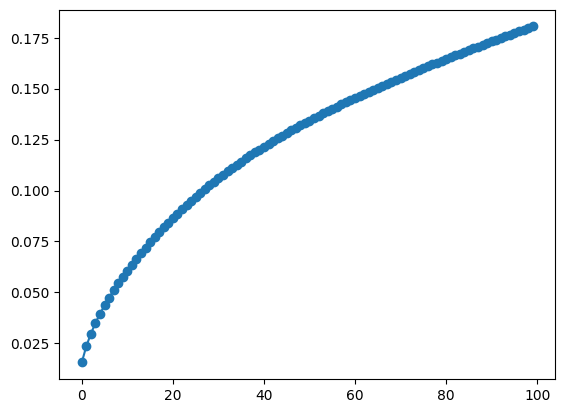

In [33]:
plt.plot(F_l, marker='o')

## EQ 8

In [34]:
s = tau / N

s = 1
N = 100

bb = b.copy()
bb_t = torch.tensor(bb, device=device, dtype=torch.complex64)
H_t = torch.tensor(H, device=device, dtype=torch.complex64)
F_l = []
for i in tqdm(range(N)):
    densi = torch.outer(bb_t, bb_t)
    # Q = torch.matrix_exp(s * (densi @ H_t - H_t @ densi))
    Q = torch.matrix_exp(s * commutator(densi, H_t))
    bb_t = Q @ bb_t
    F_l.append(abs(bb_t.cpu().numpy() @ ground_state)**2)
bb = bb_t.cpu().numpy()
result = bb
print("Fidelity with ground state:", abs(result @ ground_state)**2)
print("Result:", result)
print("Norm:", np.linalg.norm(result))
# print(np.round(result))
print(np.abs(result)**2)

100%|██████████| 100/100 [00:00<00:00, 616.00it/s]

Fidelity with ground state: 0.18058757141433546
Result: [ 2.2193923e-31+0.j  3.7470066e-12+0.j  9.9285191e-04+0.j
  2.8017741e-01+0.j  2.1930766e-14+0.j  1.1757200e-04+0.j
  2.5607798e-01+0.j  5.3924890e-03+0.j  8.8328516e-06+0.j
  1.6159745e-01+0.j  2.4006775e-02+0.j  1.3892388e-08+0.j
  7.0045672e-02+0.j  7.1975186e-02+0.j  4.4564055e-07+0.j
  7.1541572e-20+0.j  2.3531717e-11+0.j  2.4597873e-03+0.j
  3.7031537e-01+0.j  5.8101735e-04+0.j  3.1865257e-04+0.j
  3.6147654e-01+0.j  4.2127711e-03+0.j  8.8071841e-11+0.j
  2.4400854e-01+0.j  2.0137215e-02+0.j  5.6738352e-09+0.j
  3.1199177e-24+0.j  6.4660311e-02+0.j  2.0243341e-07+0.j
  9.9943742e-21+0.j  4.2038954e-45+0.j  4.9986471e-03+0.j
  4.0776601e-01+0.j  3.4623497e-04+0.j  1.7311779e-13+0.j
  4.2495596e-01+0.j  2.7168395e-03+0.j  2.5112686e-11+0.j
  1.1994296e-29+0.j  1.3991409e-02+0.j  1.8440600e-09+0.j
  2.2930739e-25+0.j  2.8025969e-45+0.j  7.3897823e-08+0.j
  1.0019808e-21+0.j  7.0064923e-45+0.j  0.0000000e+00+0.j
  3.7426761e-01+

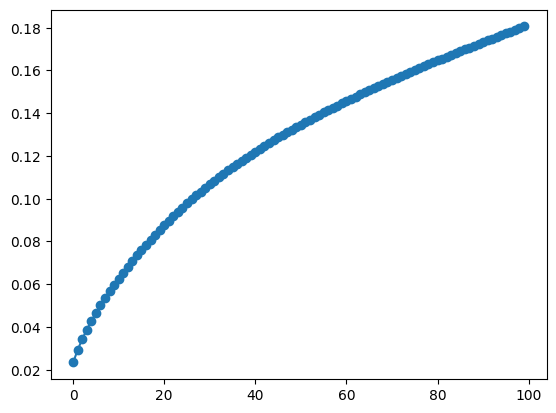

In [35]:
plt.plot(F_l, marker='o')

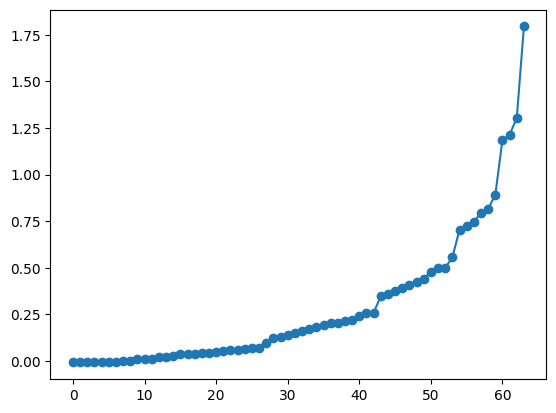

In [36]:
plt.plot(eigvals, marker='o')

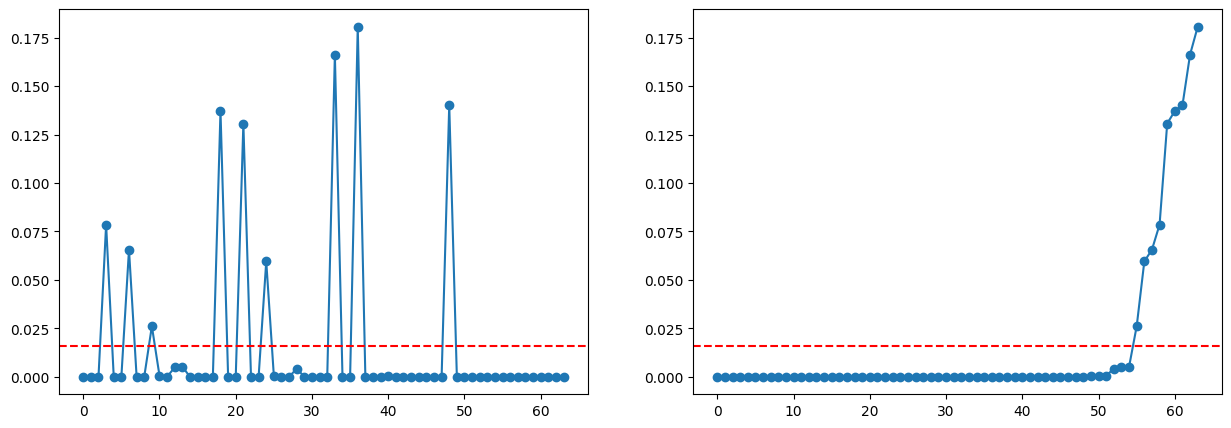

In [37]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(abs(result)**2, marker='o')
plt.axhline(y=1/(1<<TARGET_QUBIT), color='r', linestyle='--')

plt.subplot(1, 2, 2)
plt.plot(sorted(abs(result)**2), marker='o')
plt.axhline(y=1/(1<<TARGET_QUBIT), color='r', linestyle='--')

|e^ia| = 1
|e^(a + ib)| = e^a

# EQ 12


e^(iPt) = I + (e^(it) - 1)P

In [38]:
s = tau / N

s = 0.00016
N = 5

bb = b.copy()
bb_t = torch.tensor(bb, device=device, dtype=torch.complex64)
H_t = torch.tensor(H, device=device, dtype=torch.complex64)
ground_state_t = torch.tensor(ground_state, device=device, dtype=torch.complex64)
E1 = torch.matrix_exp(-1j*sqrt(s)*H_t)
E3 = torch.matrix_exp(1j*sqrt(s)*H_t)
E1_dagger = torch.adjoint(E1)
for i in tqdm(range(N)):
    densi = torch.outer(bb_t, bb_t)
    E2 = torch.matrix_exp(1j*sqrt(s)*densi)
    # E2 = torch.eye(H_t.shape[0], device=device, dtype=torch.complex64) + (np.exp(1j*sqrt(s)) - 1) * densi
    E2_dagger = torch.adjoint(E2)
    E321 = E3 @ E2 @ E1
    E321_dagger = torch.adjoint(E321)
    print("Trace of E2_dagger @ E2:", torch.trace(E2_dagger @ E2).item())
    eigvalss, eigvecss = torch.linalg.eig(E321)
    print("Eigenvalues of E321:", torch.sort(torch.abs(eigvalss)))
    bbb = bb_t.clone()
    bb_t = E321 @ bb_t
    if (i+1) % 1 == 0:
        F_k = abs(bb_t @ ground_state_t)**2
        print(f"iter {i+1}")
        print("norm of bb_t:", torch.norm(bb_t).item())
        print(f"F_{i+1}:", F_k.item())
        lower_bound = 1 - q**(i+1)
        print(f"Lower bound for F_{i+1}:", lower_bound)
        print()
    bb_t = bb_t / torch.norm(bb_t)
bb = bb_t.cpu().numpy()

print("Fidelity with ground state:", abs(bb @ ground_state)**2)
print("Result of DB-QITE:", bb)
print("Abs of DB-QITE result:", np.abs(bb) * np.sign(bb.real))
print("Norm of DB-QITE result:", np.linalg.norm(bb))

  0%|          | 0/5 [00:00<?, ?it/s]

Trace of E2_dagger @ E2: (64.00001525878906+4.529938978179576e-14j)


100%|██████████| 5/5 [00:00<00:00, 36.20it/s]

Eigenvalues of E321: torch.return_types.sort(
values=tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000], device='cuda:0'),
indices=tensor([12, 27,  4,  9, 31, 41, 52, 26, 28, 24, 17, 35, 49,  1, 10, 44,  0, 18,
        22, 38, 40, 50, 51, 54, 63,  5,  7, 14, 37, 48, 59,  2, 29, 34, 36, 42,
        57, 11, 15, 21, 32, 39, 45, 56, 62,  6,  8, 16, 19, 23, 47, 55, 43, 53,
        58, 60, 25, 33, 61, 13, 20,  3, 30, 46], device='cuda:0'))
iter 1
norm of bb_t: 1.0
F_1: 0.01562

In [39]:
print(torch.trace(E1 @ E3))
print(np.exp(-1j*sqrt(s)))

tensor(64.-2.0592e-09j, device='cuda:0')
(0.999920001066661-0.012648773333754899j)


In [40]:
print(s)

0.00016


In [41]:
# print(densi)
bbb = bbb / torch.norm(bbb)
print("Norm of bbb:", torch.norm(bbb).item())
densi = torch.outer(bbb, bbb)
# dd = torch.matrix_exp(1j*10*densi)
dd = torch.eye(H_t.shape[0], device=device, dtype=torch.complex64) + (np.exp(1j*10) - 1) * densi
dd_dagger = torch.adjoint(dd)
print(torch.trace(dd_dagger @ dd))
print(torch.diag(dd_dagger @ dd))

Norm of bbb: 1.0
tensor(64.1286-5.2220e-09j, device='cuda:0')
tensor([1.0020-2.0260e-10j, 1.0020-2.1772e-10j, 1.0020-2.2121e-10j,
        1.0020-3.0917e-10j, 1.0020-4.8376e-10j, 1.0020-2.6322e-10j,
        1.0020+2.1018e-10j, 1.0020-2.2417e-10j, 1.0020+4.7161e-10j,
        1.0020-7.6327e-11j, 1.0020-4.8152e-13j, 1.0020+3.8736e-10j,
        1.0020+4.1150e-10j, 1.0020+3.9290e-10j, 1.0020-5.1525e-10j,
        1.0020-3.2871e-10j, 1.0020+2.8683e-10j, 1.0020-4.3757e-10j,
        1.0020-4.7021e-10j, 1.0020+1.5055e-10j, 1.0020-3.1221e-10j,
        1.0020+1.4308e-10j, 1.0020-2.1323e-10j, 1.0020-3.7753e-10j,
        1.0020+1.5736e-10j, 1.0020-4.9242e-10j, 1.0020+6.4824e-11j,
        1.0020-2.1700e-10j, 1.0020+2.8788e-10j, 1.0020-3.8836e-10j,
        1.0020+2.1681e-11j, 1.0020-5.2870e-11j, 1.0020+3.4020e-10j,
        1.0020-2.3345e-10j, 1.0020-2.8656e-10j, 1.0020-1.1489e-10j,
        1.0020-2.5339e-10j, 1.0020-1.7501e-10j, 1.0020+4.6862e-10j,
        1.0020+1.4523e-11j, 1.0020-4.5032e-10j, 1.0020

In [42]:
eig_valss, eig_vecss = torch.linalg.eig(dd)
print(abs(eig_valss))
print(eig_vecss[:, 1])

tensor([1.0000, 1.0623, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000], device='cuda:0')
tensor([0.1250-1.2368e-06j, 0.1250-5.3644e-07j, 0.1250-1.3411e-07j,
        0.1250-7.4506e-09j, 0.1250-6.3330e-07j, 0.1250-1.7509e-07j,
        0.1250-3.7253e-09j, 0.1250-9.3132e-08j, 0.1250-2.2724e-07j,
        0.1250-1.8626e-08j, 0.1250-5.9605e-08j, 0.1250-3.7253e-07j,
        0.1250-3.7253e-08j, 0.1250-4.0978e-08j, 0.1250-2.9057e-07j,
        0.1250-8.6427e-07j, 0.1250-4.8801e-07j, 0.1250-1.1548e-07j

In [43]:
print(bbb)

tensor([0.1248+0.0063j, 0.1248+0.0063j, 0.1249+0.0063j, 0.1249+0.0063j,
        0.1248+0.0063j, 0.1249+0.0063j, 0.1249+0.0063j, 0.1249+0.0063j,
        0.1249+0.0063j, 0.1249+0.0063j, 0.1249+0.0063j, 0.1249+0.0063j,
        0.1249+0.0063j, 0.1249+0.0063j, 0.1249+0.0063j, 0.1248+0.0063j,
        0.1248+0.0063j, 0.1249+0.0063j, 0.1249+0.0063j, 0.1249+0.0063j,
        0.1249+0.0063j, 0.1249+0.0063j, 0.1249+0.0063j, 0.1248+0.0063j,
        0.1249+0.0063j, 0.1249+0.0063j, 0.1249+0.0063j, 0.1248+0.0063j,
        0.1249+0.0063j, 0.1249+0.0063j, 0.1248+0.0063j, 0.1248+0.0063j,
        0.1249+0.0063j, 0.1249+0.0063j, 0.1249+0.0063j, 0.1248+0.0063j,
        0.1249+0.0063j, 0.1249+0.0063j, 0.1248+0.0063j, 0.1248+0.0063j,
        0.1249+0.0063j, 0.1249+0.0063j, 0.1248+0.0063j, 0.1248+0.0063j,
        0.1249+0.0063j, 0.1248+0.0063j, 0.1248+0.0063j, 0.1248+0.0063j,
        0.1249+0.0063j, 0.1249+0.0063j, 0.1248+0.0063j, 0.1248+0.0063j,
        0.1249+0.0063j, 0.1248+0.0063j, 0.1248+0.0063j, 0.1248+0

In [154]:
k = 7
U = [None for _ in range(k+1)]
def conj(l):
    ll = [(a, b, -c) for (a, b, c) in l[::-1]]
    return ll

def dfs(n, i):
    if i == 0:
        return [("U", 0, 0)]
    if U[i] is not None:
        return U[i]
    U[i] = dfs(n, i-1) + [("H", i-1, -1)] + conj(dfs(n, i-1)) + [("D", i-1, 1)] + dfs(n, i-1) + [("H", i-1, 1)]
    return U[i]

In [155]:
dfs(k, k)
# for i in range(k+1):
#     print(f"U_{i}:", U[i])
# a = [('H', 0, 1), ('D', 0, -1)]
# print(conj(a))
type_l, tim_l, abs_l = [], [], []
for i in range(1, k+1):
    type_ll, tim_ll, abs_ll = zip(*U[i])
    type_ll = [0 if t == "H" else 1 if t == "D" else 2 for t in type_ll]
    tim_ll = np.array(tim_ll)
    abs_ll = np.array(abs_ll)
    type_ll = np.array(type_ll)
    type_l.append(type_ll)
    tim_l.append(tim_ll)
    abs_l.append(abs_ll)

# print("tim_l:", tim_l[0])
# print("abs_l:", abs_l[0])
# print("type_l:", type_l[0])\
print(U[2])

[('U', 0, 0), ('H', 0, -1), ('U', 0, 0), ('D', 0, 1), ('U', 0, 0), ('H', 0, 1), ('H', 1, -1), ('H', 0, -1), ('U', 0, 0), ('D', 0, -1), ('U', 0, 0), ('H', 0, 1), ('U', 0, 0), ('D', 1, 1), ('U', 0, 0), ('H', 0, -1), ('U', 0, 0), ('D', 0, 1), ('U', 0, 0), ('H', 0, 1), ('H', 1, 1)]


# EQ 13

In [158]:
F_l = []
for tt in range(0, k):
    time_step = [1]*(tt+1)
    type_now, tim_now, abs_now = type_l[tt], tim_l[tt], abs_l[tt]
    bb_t = torch.zeros(H.shape[0], device=device, dtype=torch.complex64)
    bb_t[0] = 1
    bb_0 = bb_t.clone()
    H_t = torch.tensor(H, device=device, dtype=torch.complex64)
    U = torch.tensor([[1, 1], [1, -1]], device=device, dtype=torch.complex64) / sqrt(2)
    UU = U.clone()
    # print(type_now.shape, tim_now.shape, abs_now.shape)
    
    for i in range(TARGET_QUBIT-1):
        UU = torch.kron(UU, U)

    e_H = torch.matrix_exp(1j*sqrt(time_step[0])*H_t)
    e_Ht = torch.matrix_exp(-1j*sqrt(time_step[0])*H_t)
    e_D = torch.matrix_exp(1j*sqrt(time_step[0])*torch.outer(bb_0, bb_0))
    e_Dt = torch.matrix_exp(-1j*sqrt(time_step[0])*torch.outer(bb_0, bb_0))
    # e_U = torch.matrix_exp(1j*sqrt(time_step[0])*UU)
    # e_Ut = torch.matrix_exp(-1j*sqrt(time_step[0])*UU)

    for i in range(type_now.shape[0]):
        if type_now[i] == 0:
            # E = torch.matrix_exp(1j*abs_now[i]*sqrt(time_step[tim_now[i]])*H_t)
            E = e_H if abs_now[i] > 0 else e_Ht
        elif type_now[i] == 1:
            densi = torch.outer(bb_0, bb_0)
            # E = torch.eye(H_t.shape[0], device=device, dtype=torch.complex64) + (np.exp(1j*sqrt(time_step[tim_now[i]])) - 1) * densi
            # E = torch.matrix_exp(1j*abs_now[i]*sqrt(time_step[tim_now[i]])*densi)
            E = e_D if abs_now[i] > 0 else e_Dt
        else:
            # E = torch.matrix_exp(1j*abs_now[i]*sqrt(time_step[tim_now[i]])*UU)
            # E = e_U if abs_now[i] > 0 else e_Ut
            E = UU
        bb_t = E @ bb_t
        # bb_t = bb_t / torch.norm(bb_t)
    F_l.append(abs(bb_t.cpu().numpy() @ ground_state)**2)
    print("Fidelity with ground state:", abs(bb_t.cpu().numpy() @ ground_state)**2)
    print("Norm of final state:", torch.norm(bb_t).item())

Fidelity with ground state: 0.02215793575369995
Norm of final state: 0.9999997019767761
Fidelity with ground state: 0.027352239051389123
Norm of final state: 0.9999988675117493
Fidelity with ground state: 0.031812416257146474
Norm of final state: 0.9999967217445374
Fidelity with ground state: 0.03579092333120176
Norm of final state: 0.9999898672103882
Fidelity with ground state: 0.03942258785425547
Norm of final state: 0.9999700784683228
Fidelity with ground state: 0.04278828742829899
Norm of final state: 0.999911367893219
Fidelity with ground state: 0.04593502200569444
Norm of final state: 0.999732494354248


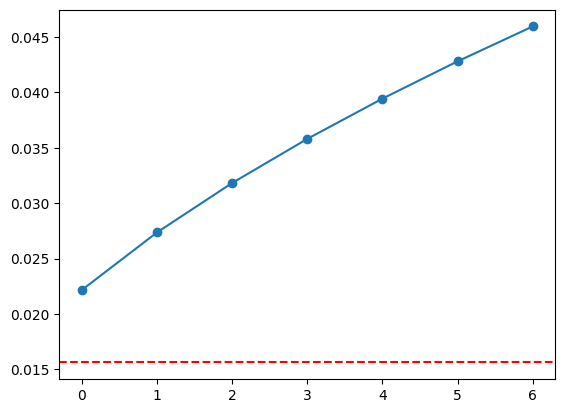

In [159]:
plt.plot(F_l, marker='o')
plt.axhline(y=1/2**TARGET_QUBIT, color='r', linestyle='--')

e^(iZt)
rz(t) = e^(-iZt/2)
rz(pi) = Z, rz(2pi) = I

In [48]:
print(H_ansatz)

(0.290123+0i) + (-0.075+0i) * Z0 + (-0.15+0i) * Z1 + (0.0563294+0i) * Z0Z1 + (-0.0624117+0i) * Z2 + (0.0233631+0i) * Z0Z2 + (-0.124823+0i) * Z3 + (0.0467262+0i) * Z0Z3 + (-0.0784169+0i) * Z4 + (0.0296316+0i) * Z0Z4 + (-0.156834+0i) * Z5 + (0.0592633+0i) * Z0Z5 + (0.0467262+0i) * Z1Z2 + (0.0934524+0i) * Z1Z3 + (0.0592633+0i) * Z1Z4 + (0.118527+0i) * Z1Z5 + (0.038983+0i) * Z2Z3 + (0.0246645+0i) * Z2Z4 + (0.0493289+0i) * Z2Z5 + (0.0493289+0i) * Z3Z4 + (0.0986579+0i) * Z3Z5 + (0.0631179+0i) * Z4Z5


e^(i(X+Y)t) = e^iXt e^iYt

In [49]:
@cudaq.kernel
def kernel_DB_QITE(step_size: List[float], qubit_count: int, idx_1: List[int], coeff_1: List[float], idx_2_a: List[int], idx_2_b: List[int], coeff_2: List[float], type_l: List[int], tim_l: List[int], abs_l: List[float]):
    qreg = cudaq.qvector(qubit_count)
    # h(qreg)

    for i in range(len(type_l)):
        # H
        if type_l[i] == 0:
            for j in range(len(idx_1)):
                rz(-2 * abs_l[i] * coeff_1[j] * np.sqrt(step_size[tim_l[i]]), qreg[idx_1[j]])
            for j in range(len(idx_2_a)):
                x.ctrl(qreg[idx_2_a[j]], qreg[idx_2_b[j]])
                rz(-2 * abs_l[i] * coeff_2[j] * np.sqrt(step_size[tim_l[i]]), qreg[idx_2_b[j]])
                x.ctrl(qreg[idx_2_a[j]], qreg[idx_2_b[j]])
        
        # D
        elif type_l[i] == 1:
            # h(qreg)
            # rz(-1 * abs_l[i] * step_size[tim_l[i]], qreg[qubit_count-1])
            # x.ctrl(qreg[0:qubit_count-1], qreg[qubit_count-1])
            # rz(-1 * abs_l[i] * step_size[tim_l[i]], qreg[qubit_count-1])
            # x.ctrl(qreg[0:qubit_count-1], qreg[qubit_count-1])
            # rz(2 * abs_l[i] * step_size[tim_l[i]], qreg[qubit_count-1])
            # h(qreg)

            ### I'M SORRY DEAR, BUT THIS IS NOT e^(i|u><u|) YOU'RE LOOKING FOR
            # h(qreg)
            x(qreg)
            rz.ctrl(1 * abs_l[i] * np.sqrt(step_size[tim_l[i]]), qreg[0:qubit_count-1], qreg[qubit_count-1])
            x(qreg)
            # h(qreg)

        # U
        elif type_l[i] == 2:
            h(qreg)

In [50]:
print(cudaq.draw(kernel_DB_QITE, [1.0]*k, TARGET_QUBIT, idx_1_use, coeff_1_use, idx_2_a_use, idx_2_b_use, coeff_2_use, type_l[1], tim_l[1], abs_l[1]))

     ╭───╮ ╭───────────╮                                                  »
q0 : ┤ h ├─┤ rz(-0.15) ├───●──────────────────●────●───────────────────●──»
     ├───┤ ├──────────┬╯ ╭─┴─╮╭────────────╮╭─┴─╮  │                   │  »
q1 : ┤ h ├─┤ rz(-0.3) ├──┤ x ├┤ rz(0.1127) ├┤ x ├──┼───────────────────┼──»
     ├───┤╭┴──────────┴─╮╰───╯╰────────────╯╰───╯╭─┴─╮╭─────────────╮╭─┴─╮»
q2 : ┤ h ├┤ rz(-0.1248) ├────────────────────────┤ x ├┤ rz(0.04673) ├┤ x ├»
     ├───┤├─────────────┤                        ╰───╯╰─────────────╯╰───╯»
q3 : ┤ h ├┤ rz(-0.2496) ├─────────────────────────────────────────────────»
     ├───┤├─────────────┤                                                 »
q4 : ┤ h ├┤ rz(-0.1568) ├─────────────────────────────────────────────────»
     ├───┤├─────────────┤                                                 »
q5 : ┤ h ├┤ rz(-0.3137) ├─────────────────────────────────────────────────»
     ╰───╯╰─────────────╯                                                 »

###########

In [51]:
print(type_l[1])

[2 0 2 1 2 0 0 0 2 1 2 0 2 1 2 0 2 1 2 0 0]


In [52]:
fid_l = []
for i in range(1, k+1):
    result = cudaq.get_state(kernel_DB_QITE, [1]*i, TARGET_QUBIT, idx_1_use, coeff_1_use, idx_2_a_use, idx_2_b_use, coeff_2_use, type_l[i-1], tim_l[i-1], abs_l[i-1])
    result_r = cudaq.get_state(kernel_flipped, result, TARGET_QUBIT)
    # print(np.array(result_r))
    uniform_state = np.ones_like(result) / np.sqrt(len(result))
    print("Fidelity with ground state:", abs(uniform_state @ ground_state)**2)
    fid = abs(result_r @ ground_state)**2
    fid_l.append(fid)
    print("Fidelity of result with ground state:", fid)
    # print("Result of DB-QITE:", np.array(result_r))

Fidelity with ground state: 0.015625
Fidelity of result with ground state: 0.02021913455587332
Fidelity with ground state: 0.015625
Fidelity of result with ground state: 0.02357205877339674
Fidelity with ground state: 0.015625
Fidelity of result with ground state: 0.02634158562637924
Fidelity with ground state: 0.015625
Fidelity of result with ground state: 0.028900089966979122
Fidelity with ground state: 0.015625
Fidelity of result with ground state: 0.031198883718316417
Fidelity with ground state: 0.015625
Fidelity of result with ground state: 0.03324226965393695
Fidelity with ground state: 0.015625
Fidelity of result with ground state: 0.035096823179785054


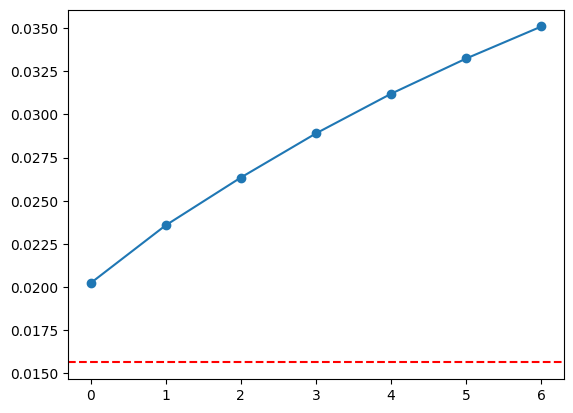

In [53]:
plt.plot(fid_l, marker='o')
plt.axhline(y=1/(1<<TARGET_QUBIT), color='r', linestyle='--')
plt.show()

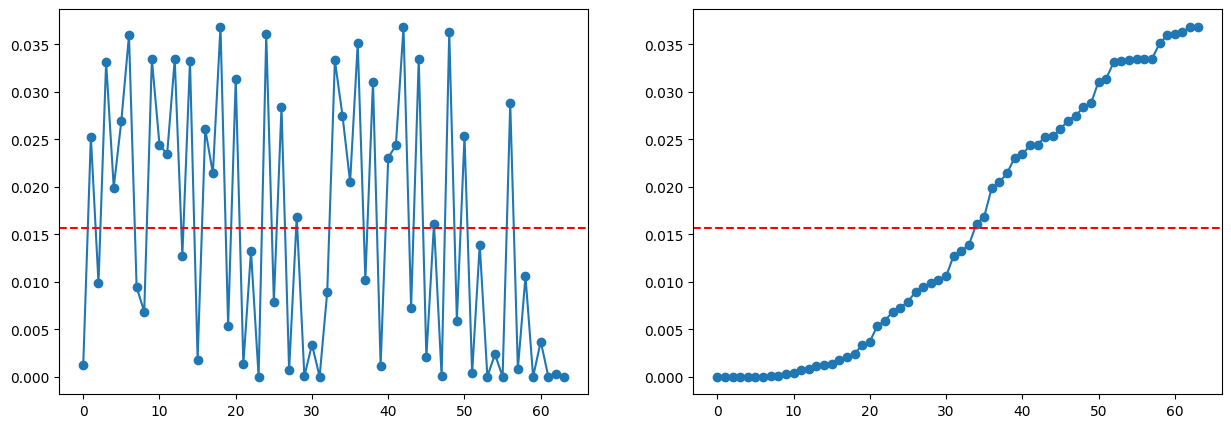

In [54]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(np.abs(result_r)**2, marker='o')
plt.axhline(y=1/(1<<TARGET_QUBIT), color='r', linestyle='--')

plt.subplot(1, 2, 2)
plt.plot(sorted(np.abs(result_r)**2), marker='o')
plt.axhline(y=1/(1<<TARGET_QUBIT), color='r', linestyle='--')
# plt.ylim(0, 1)

In [55]:
idx_gt = np.argmax(np.abs(ground_state))
idx_gt_bin = bin(idx_gt)[2:].zfill(TARGET_QUBIT)

idx_res = np.argmax(np.abs(result_r))
idx_res_min = np.argmin(np.abs(result_r))
idx_res_bin = bin(idx_res)[2:].zfill(TARGET_QUBIT)
idx_res_min_bin = bin(idx_res_min)[2:].zfill(TARGET_QUBIT)

print(f"Ground state significant indices : {idx_gt} ({idx_gt_bin})")
print(f"DB-QITE result significant indices : {idx_res} ({idx_res_bin})")
print(f"DB-QITE result minimal indices : {idx_res_min} ({idx_res_min_bin})")

Ground state significant indices : 36 (100100)
DB-QITE result significant indices : 18 (010010)
DB-QITE result minimal indices : 63 (111111)


In [56]:
print(np.array(result_r)[idx_res])
print(ground_state[idx_gt])
print(np.array(result_r) @ ground_state)

(-0.19166787-0.01066814j)
(1+0j)
(-0.18695659935474396-0.01200221385806799j)


# Debug PyTorch vs CUDA-Q

In [57]:
@cudaq.kernel
def kernel_H(idx_1: List[int], coeff_1: List[float], idx_2_a: List[int], idx_2_b: List[int], coeff_2: List[float], step_size: float, init_state: List[complex]):
    qreg = cudaq.qvector(init_state)
    for j in range(len(idx_1)):
        rz(-2 * step_size * coeff_1[j], qreg[idx_1[j]])
    for j in range(len(idx_2_a)):
        x.ctrl(qreg[idx_2_a[j]], qreg[idx_2_b[j]])
        rz(-2 * step_size * coeff_2[j], qreg[idx_2_b[j]])
        x.ctrl(qreg[idx_2_a[j]], qreg[idx_2_b[j]])

@cudaq.kernel
def kernel_D(step_size: float, qubit_count: int, init_state: List[complex]):
    qreg = cudaq.qvector(init_state)
    x(qreg)
    rz.ctrl(1 * step_size, qreg[0:qubit_count-1], qreg[qubit_count-1])
    x(qreg)

In [175]:
np.random.seed(6767)
h_sim_l, d_sim_l = [], []
for i in tqdm(range(1000)):
    b = np.ones(1<<TARGET_QUBIT) / np.sqrt(1<<TARGET_QUBIT)
    bb = np.zeros(1<<TARGET_QUBIT)
    bb[0] = 1
    r = np.random.randn(1<<TARGET_QUBIT) + 1j * np.random.randn(1<<TARGET_QUBIT)
    r = r / np.linalg.norm(r)
    # print(r[1], r[32])

    b_t = torch.tensor(b, device=device, dtype=torch.complex64)
    bb_t = torch.tensor(bb, device=device, dtype=torch.complex64)
    r_t = torch.tensor(r, device=device, dtype=torch.complex64)
    H_t = torch.tensor(H, device=device, dtype=torch.complex64)
    step_size = 1

    e_H = torch.matrix_exp(1j*sqrt(step_size)*H_t)
    state_torch = (e_H @ r_t).cpu().numpy()
    # print(state_torch)

    state_cudaq = cudaq.get_state(kernel_H, idx_1_use, coeff_1_use, idx_2_a_use, idx_2_b_use, coeff_2_use, step_size, r)
    # state_cudaq = cudaq.get_state(kernel_flipped, result, TARGET_QUBIT)
    state_cudaq = np.array(state_cudaq)
    # print(state_cudaq[1], state_cudaq[32])

    # D = torch.outer(b_t, b_t)
    D = torch.outer(bb_t, bb_t)
    e_D = torch.matrix_exp(1j*sqrt(step_size)*D)
    # eig_val, eig_vec = torch.linalg.eig(e_D)
    # print("Eigenvalues of e_D:", torch.sort(torch.abs(eig_val)))
    state_torch_D = (e_D @ r_t).cpu().numpy()
    state_cudaq_D = cudaq.get_state(kernel_D, step_size, TARGET_QUBIT, r)
    state_cudaq_D = np.array(state_cudaq_D)

    h_sim = abs(np.vdot(state_cudaq, state_torch))/(np.linalg.norm(state_cudaq)*np.linalg.norm(state_torch))
    d_sim = abs(np.vdot(state_cudaq_D, state_torch_D))/(np.linalg.norm(state_cudaq_D)*np.linalg.norm(state_torch_D))
    # print("Hamiltonian evolution similarity:", h_sim)
    # print("Diffusor evolution similarity:", d_sim)
    h_sim_l.append(h_sim)
    d_sim_l.append(d_sim)

100%|██████████| 1000/1000 [00:02<00:00, 335.31it/s]


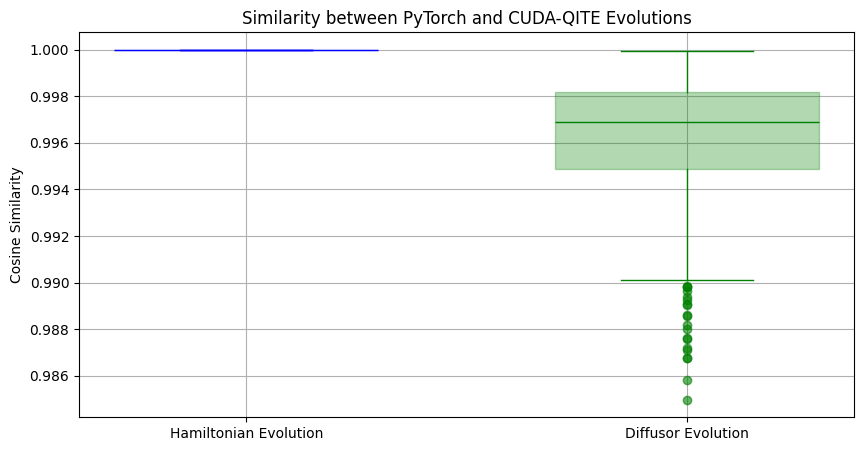

In [176]:
def box_plot(data, idx, color, width):
    ax = plt.gca()
    bp = ax.boxplot(data, positions=idx, patch_artist=True, widths=width, manage_ticks=False)
    # print(bp.keys)
    for element in ['boxes', 'whiskers', 'fliers', 'means', 'medians', 'caps']:
        plt.setp(bp[element], color=color)

    plt.setp(bp['fliers'], markerfacecolor=color, markeredgecolor=color, alpha=0.6)

    for patch in bp['boxes']:
        patch.set(facecolor=color, alpha=0.3)        
    return bp

plt.figure(figsize=(10, 5))
box_plot([h_sim_l], [1], 'blue', 0.6)
box_plot([d_sim_l], [2], 'green', 0.6)
plt.xticks([1, 2], ['Hamiltonian Evolution', 'Diffusor Evolution'])
plt.title('Similarity between PyTorch and CUDA-QITE Evolutions')
plt.ylabel('Cosine Similarity')
plt.grid(True)
plt.show()